# Title: Gaming Dataset of Popular Video Games 1980 - 2023

Business Problem: We need to determine whether video games released between 2001-2010 have significantly higher ratings than those released between 2011-2020. Understanding this trend will help us make informed decisions about game design, market preferences, and potential investment in specific genres or time periods.

Dataset Overview:
number of samples
no of features
features used
missing values

- Sources: The data has been collected from a game log/recording site called backloggd.
- Collection Methodology: Simple data scraping tools have been used such as Beautiful Soup.

Business Question: Do games released between 2001-2010 have a better player ratings compared to games released in 2011-2020 from backloggd.com.

Null Hypothesis: There is no significant difference in the average ratings of games released between 2001-2010 and 2011-2020

Alternative Hypothesis: Games released in 2001-2010 have significantly higher ratings than those in 2011-2020.

P-value is very small hence we reject the null hypothesis in favour of the alternative.

We conclude that in favour of the alternative, games made in the first range have a better rating therefore we should look into older games and find their trends and recreate them to show better experiences for people

Future Improvements: Find a way to fill in my null genre values given titles from likewise games
Genre ratings to see what genre has the best ratings

- Which genre is the most popular - world cloud

- Can find which genre have the highest ratings 

# Imports / Data load and basic EDA

In [66]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import pandas as pd

from scipy import stats
from matplotlib import pyplot as plt

import ast

%matplotlib inline

In [67]:
df = pd.read_csv(r'games.csv', index_col = 0)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              1512 non-null   object 
 1   Release Date       1512 non-null   object 
 2   Team               1511 non-null   object 
 3   Rating             1499 non-null   float64
 4   Times Listed       1512 non-null   object 
 5   Number of Reviews  1512 non-null   object 
 6   Genres             1512 non-null   object 
 7   Summary            1511 non-null   object 
 8   Reviews            1512 non-null   object 
 9   Plays              1512 non-null   object 
 10  Playing            1512 non-null   object 
 11  Backlogs           1512 non-null   object 
 12  Wishlist           1512 non-null   object 
dtypes: float64(1), object(12)
memory usage: 165.4+ KB


In [69]:
# Extract the year and put it in a new column
# Ensure 'Release Date' is a datetime column
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

# Extract the year and store it in a new column
df['Release_Year'] = df['Release Date'].dt.year

In [70]:
"""
df['Plays'] = df['Plays'].astype("int64")
df['Playing'] = df['Playing'].astype("int64")
df['Backlogs'] = df['Backlogs'].astype("int64")
df['Wishlist'] = df['Wishlist'].astype("int64")
"""

'\ndf[\'Plays\'] = df[\'Plays\'].astype("int64")\ndf[\'Playing\'] = df[\'Playing\'].astype("int64")\ndf[\'Backlogs\'] = df[\'Backlogs\'].astype("int64")\ndf[\'Wishlist\'] = df[\'Wishlist\'].astype("int64")\n'

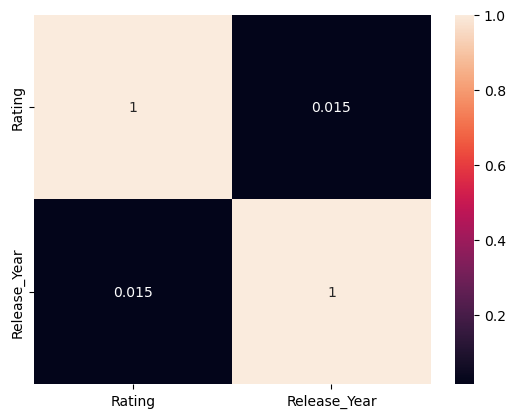

In [71]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [72]:
df.shape

(1512, 14)

In [73]:
df.head()

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Release_Year
0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K,2022.0
1,Hades,2019-12-10,['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K,2019.0
2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K,2017.0
3,Undertale,2015-09-15,"['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K,2015.0
4,Hollow Knight,2017-02-24,['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K,2017.0


In [74]:
df.tail()

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Release_Year
1507,Back to the Future: The Game,2010-12-22,['Telltale Games'],3.2,94,94,"['Adventure', 'Point-and-Click']",Back to the Future: The Game is one of Telltal...,['Very enjoyable game. The story adds onto the...,763,5,223,67,2010.0
1508,Team Sonic Racing,2019-05-21,"['Sumo Digital', 'Sega']",2.9,264,264,"['Arcade', 'Racing']",Team Sonic Racing combines the best elements o...,"['jogo morto mas bom', 'not my cup of tea', ""C...",1.5K,49,413,107,2019.0
1509,Dragon's Dogma,2012-05-22,['Capcom'],3.7,210,210,"['Brawler', 'RPG']","Set in a huge open world, Dragon’s Dogma: Dark...","['Underrated.', 'A grandes rasgos, es como un ...",1.1K,45,487,206,2012.0
1510,Baldur's Gate 3,2020-10-06,['Larian Studios'],4.1,165,165,"['Adventure', 'RPG', 'Strategy', 'Tactical', '...","An ancient evil has returned to Baldur's Gate,...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,269,79,388,602,2020.0
1511,The LEGO Movie Videogame,2014-02-04,"['WB Games', 'TT Fusion']",2.8,184,184,"['Adventure', 'Puzzle']",Join Emmet and an unlikely group of resistance...,"['Legal', 'Pretty Average Lego Game But It Was...",1.7K,11,239,73,2014.0


## Datatype Conversion

In [75]:
df.dtypes

Title                        object
Release Date         datetime64[ns]
Team                         object
Rating                      float64
Times Listed                 object
Number of Reviews            object
Genres                       object
Summary                      object
Reviews                      object
Plays                        object
Playing                      object
Backlogs                     object
Wishlist                     object
Release_Year                float64
dtype: object

In [76]:
# Convert the Release Date column to datetime
df['Release Date'] = pd.to_datetime(df['Release Date'], errors = 'coerce')

Comments: Changed release date type to Date/time format, had to use errors argument to ignore incorrect values which will be adjusted later.

In [77]:
df.head()

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Release_Year
0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K,2022.0
1,Hades,2019-12-10,['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K,2019.0
2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K,2017.0
3,Undertale,2015-09-15,"['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K,2015.0
4,Hollow Knight,2017-02-24,['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K,2017.0


## Duplicate Check

In [78]:
df['Duplicate_Status'] = np.where(df["Title"].duplicated(keep='first'), 'Duplicate', 'Unique') #Creates a new duplicate status column which runs through the dataset, keeps the first instance of every title as unique and the next as duplicates

In [79]:
df["Duplicate_Status"].value_counts() #Unique vs Duplicate check

Duplicate_Status
Unique       1099
Duplicate     413
Name: count, dtype: int64

In [80]:
df[df["Duplicate_Status"] == "Duplicate"] #Prints Duplicate rows

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Release_Year,Duplicate_Status
132,Doom,1993-12-10,"['Activision', 'id Software']",4.0,1.4K,1.4K,['Shooter'],"In the future, humans have left Earth and sett...","['Recomendadisimo', 'classic', 'doom my belove...",11K,203,1.5K,514,1993.0,Duplicate
159,Dead Space,2008-10-14,"['EA Redwood Shores', 'Electronic Arts']",4.0,1.2K,1.2K,['Shooter'],Dead Space is a 2008 science fiction survival ...,['Impressionante demais pra Ã©poca e realmente...,9.6K,302,2.7K,1.1K,2008.0,Duplicate
161,Shadow of the Colossus,2018-02-06,"['Sony Interactive Entertainment', 'Bluepoint ...",4.1,1.1K,1.1K,"['Adventure', 'Platform', 'Puzzle']",Tales speak of an ancient land where creatures...,['(Played before 2023)\n \...,7.8K,242,3.2K,1.6K,2018.0,Duplicate
163,God of War,2005-03-22,"['SCE Santa Monica Studio', 'Sony Computer Ent...",3.6,981,981,"['Adventure', 'Brawler', 'Strategy']","Similar to franchises like Devil May Cry, Ryga...","['As a god of war game, It s incredible\n ...",11K,158,1.5K,896,2005.0,Duplicate
326,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K,2022.0,Duplicate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,Fatal Frame II: Crimson Butterfly,2003-11-27,"['Tecmo Co., Ltd.', 'Ubisoft Entertainment']",4.2,398,398,['Adventure'],Crimson Butterfly is the second installment in...,['Pretty cool albeit a bit similar to the firs...,1K,38,690,513,2003.0,Duplicate
1282,Super Mario Sunshine,2020-09-18,"['Nintendo EAD', 'Nintendo']",3.7,19,19,"['Adventure', 'Platform']",A port of Super Mario Sunshine included in Sup...,['What an amazing remaster of an already amazi...,340,6,83,14,2020.0,Duplicate
1332,Doom,2017-11-10,"['Bethesda Softworks', 'id Software']",3.9,80,80,['Shooter'],"Doom, the brutally fun and challenging modern-...",['can we get a Doom anime. Now I would watch t...,2.3K,37,393,150,2017.0,Duplicate
1492,Sonic the Hedgehog 2,1992-10-16,"['Aspect Co. Ltd', 'Sega']",2.8,157,157,"['Adventure', 'Arcade', 'Platform']",This is a completely different game than its 1...,['Played as part of Sonic Gems Collection on t...,1.4K,6,173,45,1992.0,Duplicate


In [81]:
# Drop rows where 'Duplicate_Status' is 'Duplicate'
df = df.drop(df[df['Duplicate_Status'] == 'Duplicate'].index)
# Reset index to maintain order
df.reset_index(drop=True, inplace=True)

In [82]:
df.tail()

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Release_Year,Duplicate_Status
1094,Back to the Future: The Game,2010-12-22,['Telltale Games'],3.2,94,94,"['Adventure', 'Point-and-Click']",Back to the Future: The Game is one of Telltal...,['Very enjoyable game. The story adds onto the...,763,5,223,67,2010.0,Unique
1095,Team Sonic Racing,2019-05-21,"['Sumo Digital', 'Sega']",2.9,264,264,"['Arcade', 'Racing']",Team Sonic Racing combines the best elements o...,"['jogo morto mas bom', 'not my cup of tea', ""C...",1.5K,49,413,107,2019.0,Unique
1096,Dragon's Dogma,2012-05-22,['Capcom'],3.7,210,210,"['Brawler', 'RPG']","Set in a huge open world, Dragon’s Dogma: Dark...","['Underrated.', 'A grandes rasgos, es como un ...",1.1K,45,487,206,2012.0,Unique
1097,Baldur's Gate 3,2020-10-06,['Larian Studios'],4.1,165,165,"['Adventure', 'RPG', 'Strategy', 'Tactical', '...","An ancient evil has returned to Baldur's Gate,...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,269,79,388,602,2020.0,Unique
1098,The LEGO Movie Videogame,2014-02-04,"['WB Games', 'TT Fusion']",2.8,184,184,"['Adventure', 'Puzzle']",Join Emmet and an unlikely group of resistance...,"['Legal', 'Pretty Average Lego Game But It Was...",1.7K,11,239,73,2014.0,Unique


In [83]:
df["Duplicate_Status"].value_counts()

Duplicate_Status
Unique    1099
Name: count, dtype: int64

## Dealing with Null/Missing Values

In [84]:
df.isnull().sum()

Title                 0
Release Date          3
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
Release_Year          3
Duplicate_Status      0
dtype: int64

Comments: We can see missing values from 4 different columns, release date, team, rating, and summary.
- Rows with missing date will be dropped. As its a small number of rows, it will not be detrimental to the results.
- Row with missing team will be renamed to "Unknown". Ideally as the information is available online I could find the results and change it.
- Rows with missing rating will be transformed to be filled with the mean value of all the ratings.
- During inspection for ratings I found rows with missing genres. As there were only 3 rows, I decided to drop the rows as it would not have a huge impact on the results.

### Release Date

In [85]:
missing_date = np.where(df["Release Date"].isna())[0]  # Extract actual indices where team is null

In [86]:
#Drops from indexes where date is NaT
df.drop(index=missing_date, inplace=True)
# Reset index to maintain order
df.reset_index(drop=True, inplace=True)

In [87]:
df.isnull().sum()

Title                 0
Release Date          0
Team                  1
Rating               12
Times Listed          0
Number of Reviews     0
Genres                0
Summary               0
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
Release_Year          0
Duplicate_Status      0
dtype: int64

### Team

In [88]:
print(np.where(df["Team"].isna() == True)) #Where team is null

(array([853], dtype=int64),)


In [89]:
df.at[853, 'Team'] = str(['Unknown Publisher'])  #NaN publisher changed to unknown publisher, written in the same format as other publishers in string type

In [90]:
df.iloc[853]

Title                                             NEET Girl Date Night
Release Date                                       2022-10-21 00:00:00
Team                                             ['Unknown Publisher']
Rating                                                             2.7
Times Listed                                                        21
Number of Reviews                                                   21
Genres                                                ['Visual Novel']
Summary              Your friend sets you up on a date with his NEE...
Reviews              ['this sucked. "Omg she is literally me" is no...
Plays                                                              106
Playing                                                              1
Backlogs                                                            44
Wishlist                                                            42
Release_Year                                                    2022.0
Duplic

In [91]:
df.isnull().sum()

Title                 0
Release Date          0
Team                  0
Rating               12
Times Listed          0
Number of Reviews     0
Genres                0
Summary               0
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
Release_Year          0
Duplicate_Status      0
dtype: int64

### Rating

In [92]:
print(np.where(df["Rating"].isna() == True)) #Where rating is null

(array([366, 481, 487, 494, 513, 602, 741, 770, 812, 892, 927, 935],
      dtype=int64),)


In [93]:
df['Rating'] = df['Rating'].fillna(np.round(df['Rating'].mean(), 1)) #fills in all missing values with the mean of the rating values, values are rounded to 1sf

In [94]:
df.isnull().sum()

Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
Release_Year         0
Duplicate_Status     0
dtype: int64

### Genres

In [95]:
# Find rows where 'Genres' is an empty list or an empty string
missing_genres = df[df['Genres'].isin(['[]', ''])]
missing_genres_rows = missing_genres.index.tolist()
# Display the indices of such rows
print(missing_genres_rows)

[481, 896, 1061]


In [96]:
#Drops from indexes where date is NaT
df.drop(index=missing_genres_rows, inplace=True)
# Reset index to maintain order
df.reset_index(drop=True, inplace=True)

In [97]:
#df[df['Title'].str.contains('Final Fantasy VII')] 

## Drop Unwanted Columns


In [98]:
df = df.drop(columns=["Summary", "Reviews", "Plays", "Playing", "Backlogs", "Wishlist", "Duplicate_Status", "Times Listed", "Number of Reviews"]) #Drop summary, reviews, plays, playing, backlogs, wishlist, times lsited, number of reviews, duplicate status

Comments:
The only columns I need is title, release date, and rating. I've personally kept in team and genres for other calculations.

## Adding New Column for easier comparison

In [99]:
# Extract the year and put it in a new column
df['Release_Year'] = df['Release Date'].dt.year

In [100]:
# Move the 5th column (index 4) to the 2nd position (index 1)
columns = df.columns.tolist()  # Get the current column order
# Remove the 5th column and insert it at the 2nd position
columns.insert(1, columns.pop(5))

# Reorder the DataFrame with the new column order
df = df[columns]

In [101]:
df

,Title,Release_Year,Release Date,Team,Rating,Genres
0,Elden Ring,2022,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,"['Adventure', 'RPG']"
1,Hades,2019,2019-12-10,['Supergiant Games'],4.3,"['Adventure', 'Brawler', 'Indie', 'RPG']"
2,The Legend of Zelda: Breath of the Wild,2017,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,"['Adventure', 'RPG']"
3,Undertale,2015,2015-09-15,"['tobyfox', '8-4']",4.2,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra..."
4,Hollow Knight,2017,2017-02-24,['Team Cherry'],4.4,"['Adventure', 'Indie', 'Platform']"
...,...,...,...,...,...,...
1088,Back to the Future: The Game,2010,2010-12-22,['Telltale Games'],3.2,"['Adventure', 'Point-and-Click']"
1089,Team Sonic Racing,2019,2019-05-21,"['Sumo Digital', 'Sega']",2.9,"['Arcade', 'Racing']"
1090,Dragon's Dogma,2012,2012-05-22,['Capcom'],3.7,"['Brawler', 'RPG']"
1091,Baldur's Gate 3,2020,2020-10-06,['Larian Studios'],4.1,"['Adventure', 'RPG', 'Strategy', 'Tactical', '..."


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Title         1093 non-null   object        
 1   Release_Year  1093 non-null   int32         
 2   Release Date  1093 non-null   datetime64[ns]
 3   Team          1093 non-null   object        
 4   Rating        1093 non-null   float64       
 5   Genres        1093 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(1), object(3)
memory usage: 47.1+ KB


In [103]:
df[['Release_Year', 'Rating']].corr(method='pearson')

,Release_Year,Rating
Release_Year,1.000000,0.000309
Rating,0.000309,1.000000


# Calculations

In [104]:
year_range_1 = df[(df["Release_Year"] >= 2001) & (df["Release_Year"] <= 2010)] #Pulls rows of Years between 2001-2010 
year_range_2 = df[(df["Release_Year"] >= 2011) & (df["Release_Year"] <= 2020)] #Pulls rows of Years between 2011-2020

In [105]:
year_range_1_ratings = year_range_1["Rating"]
year_range_2_ratings = year_range_2["Rating"]

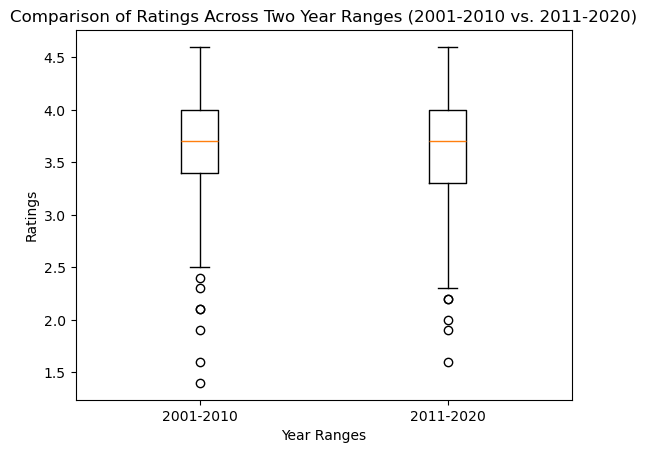

In [106]:
data = [year_range_1_ratings, year_range_2_ratings]
_ = plt.boxplot(data, tick_labels = ["2001-2010", "2011-2020"])
plt.xlabel('Year Ranges') #x axis label
plt.ylabel('Ratings') #y axis label
plt.title ('Comparison of Ratings Across Two Year Ranges (2001-2010 vs. 2011-2020)') #title for graph
plt.show()

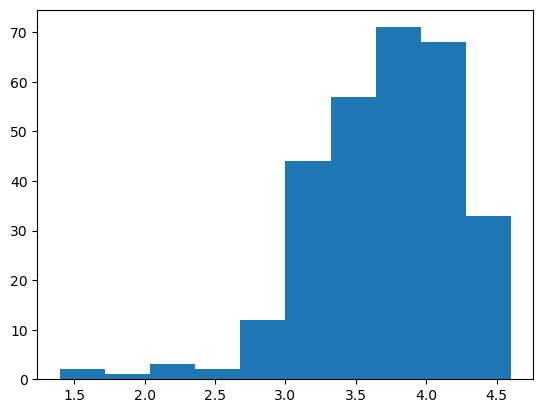

In [107]:
_ = plt.hist(year_range_1_ratings)
plt.show()

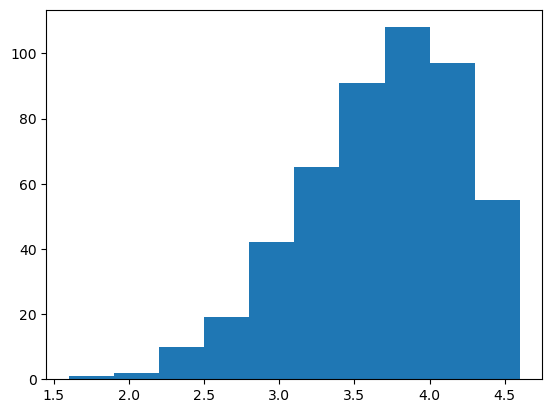

In [108]:
_ = plt.hist(year_range_2_ratings)
plt.show()

In [109]:
year_range_1_ratings.describe()

count    293.000000
mean       3.692833
std        0.507394
min        1.400000
25%        3.400000
50%        3.700000
75%        4.000000
max        4.600000
Name: Rating, dtype: float64

In [110]:
year_range_2_ratings.describe()

count    490.000000
mean       3.625714
std        0.538110
min        1.600000
25%        3.300000
50%        3.700000
75%        4.000000
max        4.600000
Name: Rating, dtype: float64

There were almost 200 more game counts between 2011-2020 compared to 2001-2010.
The lowest rated game was at 1.4 compared to 1.6 in the first range.
Overall games were rated higher in 2001-2010
Both ranges had a max rating of 4.6

In [111]:
game_range_sample_2001_2010 = year_range_1_ratings.sample(100, random_state= 25)
game_range_sample_2011_2020 = year_range_2_ratings.sample(100, random_state= 25)

N = 100
alpha = 0.05

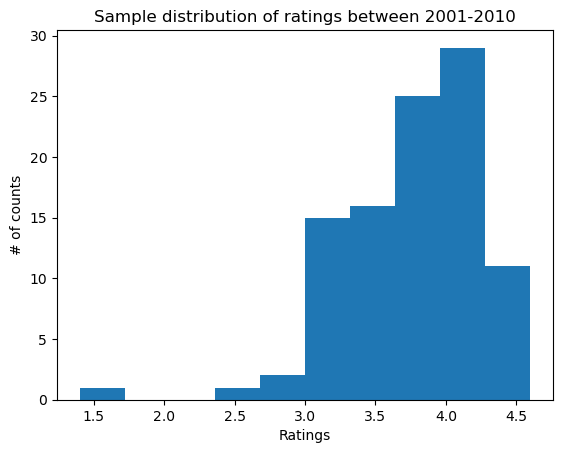

In [112]:
_ = plt.hist(game_range_sample_2001_2010)
plt.xlabel('Ratings') #x axis label
plt.ylabel('# of counts') #y axis label
plt.title ('Sample distribution of ratings between 2001-2010') #title for graph
plt.show()

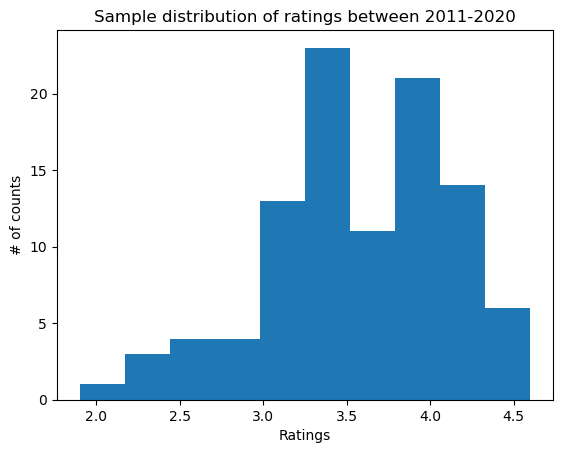

In [113]:
_ = plt.hist(game_range_sample_2011_2020)
plt.xlabel('Ratings') #x axis label
plt.ylabel('# of counts') #y axis label
plt.title ('Sample distribution of ratings between 2011-2020') #title for graph
plt.show()

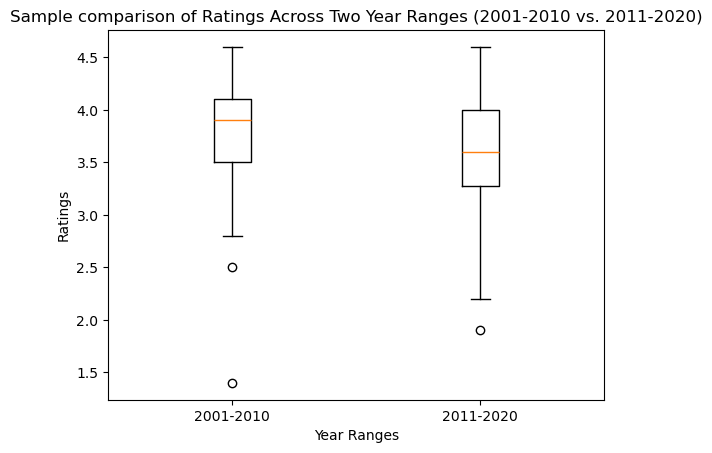

In [114]:
data = [game_range_sample_2001_2010, game_range_sample_2011_2020]
_ = plt.boxplot(data, tick_labels = ["2001-2010", "2011-2020"])
plt.xlabel('Year Ranges') #x axis label
plt.ylabel('Ratings') #y axis label
plt.title ('Sample comparison of Ratings Across Two Year Ranges (2001-2010 vs. 2011-2020)') #title for graph
plt.show()

In [115]:
## Calculate the variance to get the standard deviation
var_a = game_range_sample_2001_2010.var(ddof = 1)
var_b = game_range_sample_2011_2020.var(ddof = 1)

## Calculate the Standard Deviation
s = np.sqrt((var_a + var_b)/2)
print(s)

0.516045569986828


In [116]:
t_test = (game_range_sample_2001_2010.mean() - game_range_sample_2011_2020.mean()) / (s * np.sqrt(2 / N))  # t-statistic
t_test

2.521243380534123

In [117]:
## Compare with the critical t-value
## Degrees of freedom
ddof = 2*N - 2

#p-value after comparison with the t
if (t_test > 0):
    p = 1*(1 - stats.t.cdf(t_test, df = ddof))
else:
    p = 1*stats.t.cdf(t_test, df = ddof)

In [118]:
print("t = " + str(t_test))
print("p = " + str(p))

t = 2.521243380534123
p = 0.006241213925401334


In [119]:
def print_sig(p_value, alpha):
    if p_value < alpha:
        print("We reject our null hypothesis in favour of the alternative.")
    else:
        print("We fail to reject our null hypothesis.")

In [120]:
## Cross Checking with the internal scipy function
t2, p2 = stats.ttest_ind(game_range_sample_2001_2010, game_range_sample_2011_2020, alternative="greater")
print("t = " + str(t2))
print("p = " + str(p2))

print_sig(p2, alpha)

t = 2.5212433805341226
p = 0.00624121392540133
We reject our null hypothesis in favour of the alternative.


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Title         1093 non-null   object        
 1   Release_Year  1093 non-null   int32         
 2   Release Date  1093 non-null   datetime64[ns]
 3   Team          1093 non-null   object        
 4   Rating        1093 non-null   float64       
 5   Genres        1093 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(1), object(3)
memory usage: 47.1+ KB


# Bonus: Convert Genre and Team to strings to collect Counts

In [122]:
# Convert the 'Genres' column from string to actual lists
df['Genres'] = df['Genres'].apply(ast.literal_eval) #Can not be rerun

# Flatten the list and count occurrences
genre_counts = pd.Series([genre for sublist in df['Genres'] for genre in sublist]).value_counts()
# Print the top genres
print(genre_counts)
type(genre_counts)

Adventure              710
RPG                    360
Shooter                255
Platform               236
Indie                  206
Puzzle                 128
Strategy               114
Brawler                105
Simulator               92
Turn Based Strategy     70
Fighting                63
Arcade                  60
Visual Novel            52
Tactical                42
Racing                  37
Point-and-Click         36
Music                   20
Sport                   20
Card & Board Game       13
Real Time Strategy       9
Quiz/Trivia              3
MOBA                     2
Pinball                  1
Name: count, dtype: int64


pandas.core.series.Series

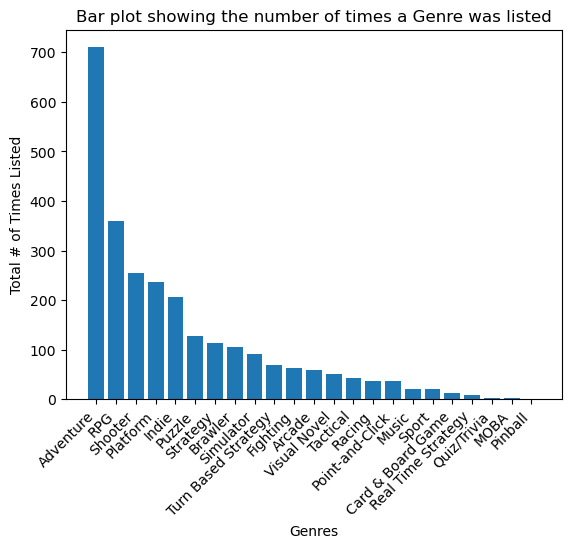

In [123]:
_ = plt.bar(genre_counts.index, genre_counts.values, align='center')

# Add labels and title
plt.xlabel('Genres')
plt.xticks(rotation=45, ha='right') #xlabels rotated for visibility
plt.ylabel('Total # of Times Listed')
plt.title('Bar plot showing the number of times a Genre was listed')

plt.show()

In [124]:
# Convert 'Team' from string to list (if needed)
df['Team'] = df['Team'].apply(ast.literal_eval) #Can not be rerun

# Flatten the list and count occurrences
team_counts = pd.Series([team for sublist in df['Team'] for team in sublist]).value_counts()

# Print the top teams
print(team_counts)

Nintendo            170
Capcom               62
Square Enix          56
Sega                 44
Electronic Arts      42
                   ... 
Warhorse Studios      1
Cold Symmetry         1
Playstack             1
ThatGameCompany       1
TT Fusion             1
Name: count, Length: 662, dtype: int64


In [125]:
"""
_ = plt.bar(team_counts.index, team_counts.values)

# Add labels and title
plt.xlabel('Developers')
plt.xticks(rotation=45, ha='right') #xlabels rotated for visibility
plt.ylabel('Total # of Times Listed')
plt.title('Bar plot showing the number of times a Developer was listed')

plt.show()
"""
#Wont work as there are too many developers

"\n_ = plt.bar(team_counts.index, team_counts.values)\n\n# Add labels and title\nplt.xlabel('Developers')\nplt.xticks(rotation=45, ha='right') #xlabels rotated for visibility\nplt.ylabel('Total # of Times Listed')\nplt.title('Bar plot showing the number of times a Developer was listed')\n\nplt.show()\n"